Purpose: Set up downsampled datasets for *Y. gloriosa* maSigPro runs: 10 counts dataframes of 3 replicates per condition each (randomly selected with no replacement), for each of 3 physiological categories (based on titratable acidity classifications).<br>
Author: Anna Pardo<br>
Date initiated: Apr. 15, 2026

In [1]:
import pandas as pd
import numpy as np
import json
import os

In [2]:
# load physiological category data (new from TA)
taphys = pd.read_csv("../physiology/final_TA_classes.csv",sep=",",header="infer")
taphys.head()

,Genotype,TA class after T-test
0,18,C3+CAM
1,19,C3+CAM
2,36,C3+CAM
3,45,C3+CAM
4,46,C3+CAM


In [3]:
taphys.rename(columns={"Genotype":"genotype","TA class after T-test":"physiology"},inplace=True)

In [4]:
# load counts
counts = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/counts/Yg_toYgIS_all_md_countsmatrix_over1mil.txt",
                    sep="\t",header="infer")
counts.head()

/tmp/ipykernel_3980/168404881.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  counts = pd.read_csv("/home/leviathan22/Yucca_genomics/rna_insilico_genome/counts/Yg_toYgIS_all_md_countsmatrix_over1mil.txt",


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g,Total_Reads
0,Y1,18,1.0,W,1.0,gloriosa,745,50,0,536,...,42,26,14,196,10,34,173,0,0,12458673
1,Y10,2AB,1.5,W,3.0,gloriosa,176,8,0,93,...,3,57,12,35,0,8,63,0,0,2479905
2,Y100,2AB,6.5,W,23.0,gloriosa,472,26,0,246,...,7,179,41,80,12,17,297,0,3,6344543
3,SRR10848707,55,4.0,D,13.0,gloriosa,523,70,0,232,...,22,404,41,70,142,29,84,0,3,10585018
4,SRR10848820,70,4.0,D,13.0,gloriosa,943,136,0,668,...,81,65,59,215,144,100,298,0,0,21651248


In [5]:
counts["genotype"] = counts["genotype"].astype(str)
counts["genotype"].unique()

array(['18', '2AB', '55', '70', '61', '51', '1AB', '19', '15', 'Eudy',
       'G', '56', '36', '13', '13.0', '18.0', '45.0', '45', '52', '46',
       '43', '37', '53', '48', '51.0', '36.0', '16', '6', '12', '20',
       '50'], dtype=object)

In [6]:
gtmap = {}
for i in counts["genotype"].unique():
    if i.endswith(".0"):
        gtmap[i] = i.rstrip(".0")
    else:
        gtmap[i] = i

In [7]:
counts["genotype"] = counts["genotype"].map(gtmap)
counts["genotype"].unique()

array(['18', '2AB', '55', '70', '61', '51', '1AB', '19', '15', 'Eudy',
       'G', '56', '36', '13', '45', '52', '46', '43', '37', '53', '48',
       '16', '6', '12', '20', '50'], dtype=object)

In [8]:
taphys["genotype"].unique()

array(['18', '19', '36', '45', '46', '48', '55', '70', '1AB', '2AB', '12',
       '16', '37', '51', '52', '53', '56', '43', '13', '15', '20', '61',
       'Eudy', 'G'], dtype=object)

In [9]:
# make taphys into a dict & save as json for future use
physdict = {}
for i in range(len(taphys.index)):
    physdict[taphys.iloc[i,0]] = taphys.iloc[i,1]

In [11]:
with open("../physiology/physiological_categories_from_TA.json","w+") as outfile:
    json.dump(physdict,outfile)

In [10]:
counts["phys"] = counts["genotype"].map(physdict)

In [12]:
def getrepsphys(pdf,nreps=3):
    dfl = []
    for t in pdf["treat"].unique():
        sdf = pdf[pdf["treat"]==t]
        for z in [1.0,5.0,9.0,13.0,17.0,21.0]:
            if z in list(sdf["ZT"]):
                sdf2 = sdf[sdf["ZT"]==z]
                dfl.append(sdf2.sample(n=nreps,axis=0))
    randreps = pd.concat(dfl)
    # also return subset dataframe (to help the no-replacement condition)
    #subdf = pdf[~pdf["sample_name"].isin(list(randreps["sample_name"]))]
    # commented out because as per sample numbers below, I have to do this with replacement actually
    return randreps

In [13]:
classes = list(set(list(physdict.values())))

In [14]:
for i in classes:
    print(i+" "+str(len(counts[counts["phys"]==i].index)))

C3+CAM 439
facultative CAM 157
CAM 231


In [15]:
# function to make & save the 10 dataframes for each physiology
## WITH replacement
def input_data_setup(phys,n=10,data=counts):
    d = "./"+phys+"_inputdata_maSigPro"
    if not os.path.exists(d):
        os.makedirs(d)
    x = 1
    while x<(n+1):
        df = getrepsphys(data[data["phys"]==phys])
        df.to_csv(os.path.join(d,phys+"_"+str(x)+"_3reps_msp_input.txt"),sep="\t",header=True,index=False)
        x+=1

In [32]:
for i in classes:
    input_data_setup(i)

In [16]:
# re-define input_data_setup() for taking 3 more random sets of C3+CAM data
def input_data_setup(phys,n=3,data=counts):
    d = "./"+phys+"_newsets_inputdata_maSigPro"
    if not os.path.exists(d):
        os.makedirs(d)
    x = 1
    while x<(n+1):
        df = getrepsphys(data[data["phys"]==phys])
        df.to_csv(os.path.join(d,phys+"_"+str(x)+"_3reps_msp_input.txt"),sep="\t",header=True,index=False)
        x+=1

In [17]:
input_data_setup("C3+CAM")

In [2]:
# determine what samples/genotypes were included in each input file
def extract_md(filepath):
    df = pd.read_csv(filepath,sep="\t",header="infer",usecols=["sample_name","genotype","phys"])
    df["filename"] = os.path.basename(filepath)
    return df

In [36]:
mdlist = []
for f in os.listdir("./"):
    if f.endswith("maSigPro"):
        d = os.path.join("./",f)
        for i in os.listdir(d):
            mdlist.append(extract_md(os.path.join(d,i)))

/tmp/ipykernel_380/4164133094.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath,sep="\t",header="infer",usecols=["sample_name","genotype","phys"])
/tmp/ipykernel_380/4164133094.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath,sep="\t",header="infer",usecols=["sample_name","genotype","phys"])
/tmp/ipykernel_380/4164133094.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath,sep="\t",header="infer",usecols=["sample_name","genotype","phys"])
/tmp/ipykernel_380/4164133094.py:3: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath,sep="\t",header="infer",usecols=["sample_name","genotype","phys"])
/tmp/ipykernel_380/4164133094.py:3: DtypeWarning: Columns (1) have mixed typ

In [38]:
allmd = pd.concat(mdlist)

In [55]:
cammd = {}
for f in os.listdir("./CAM_inputdata_maSigPro/"):
    x = f.split("_")[0]+"_"+f.split("_")[1]
    cammd[x] = pd.read_csv(os.path.join("./CAM_inputdata_maSigPro/",f),sep="\t",header="infer",usecols=["genotype"])

In [64]:
counts = {}

for k, df in cammd.items():
    counts[k] = df["genotype"].astype(str).value_counts()

counts_df = pd.DataFrame(counts).fillna(0)

In [65]:
percent_df = counts_df.div(counts_df.sum(axis=0), axis=1) * 100

In [69]:
percent_df = percent_df[["CAM_1","CAM_2","CAM_3","CAM_4","CAM_5","CAM_6","CAM_7","CAM_8","CAM_9","CAM_10"]]

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

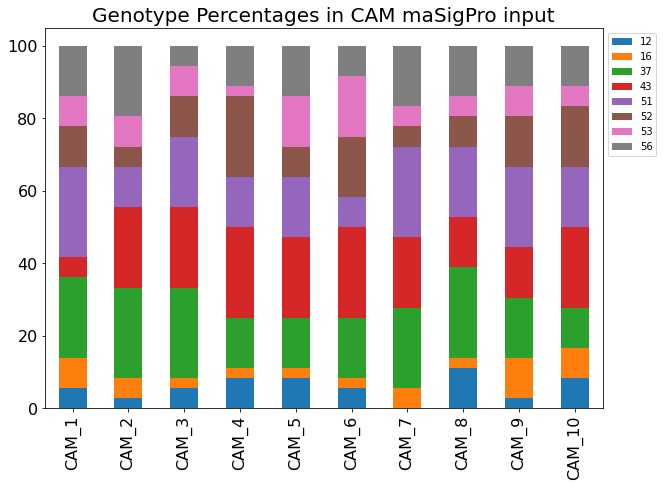

In [80]:
percent_df.T.plot(
    kind="bar",
    stacked=True,
    figsize=(10,7)
)
plt.legend(bbox_to_anchor=(1,1))
plt.tick_params(which="both",labelsize=16)
plt.title("Genotype Percentages in CAM maSigPro input",fontsize=20)
plt.savefig("./cam_gtpct.svg",dpi=300,bbox_inches="tight")

In [84]:
# make this a function
def plot_gtpct(d):
    phys = d.split("_")[0].lstrip("./")
    md = {}
    for f in os.listdir(d):
        if not f.startswith("."):
            x = f.split("_")[0]+"_"+f.split("_")[1]
            md[x] = pd.read_csv(os.path.join(d,f),sep="\t",header="infer",usecols=["genotype"])
        
    counts = {}
    for k, df in md.items():
        counts[k] = df["genotype"].astype(str).value_counts()

    counts_df = pd.DataFrame(counts).fillna(0)
    percent_df = counts_df.div(counts_df.sum(axis=0), axis=1) * 100
    percent_df = percent_df[[phys+"_1",phys+"_2",phys+"_3",phys+"_4",phys+"_5",phys+"_6",phys+"_7",phys+"_8",
                             phys+"_9",phys+"_10"]]
    
    percent_df.T.plot(
        kind="bar",
        stacked=True,
        figsize=(10,7)
    )
    plt.legend(bbox_to_anchor=(1,1))
    plt.tick_params(which="both",labelsize=16)
    plt.title("Genotype Percentages in "+phys+" maSigPro input",fontsize=20)
    plt.savefig("./"+phys+"_gtpct.svg",dpi=300,bbox_inches="tight")

/tmp/ipykernel_380/944756710.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d,f),sep="\t",header="infer",usecols=["genotype"])
/tmp/ipykernel_380/944756710.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d,f),sep="\t",header="infer",usecols=["genotype"])


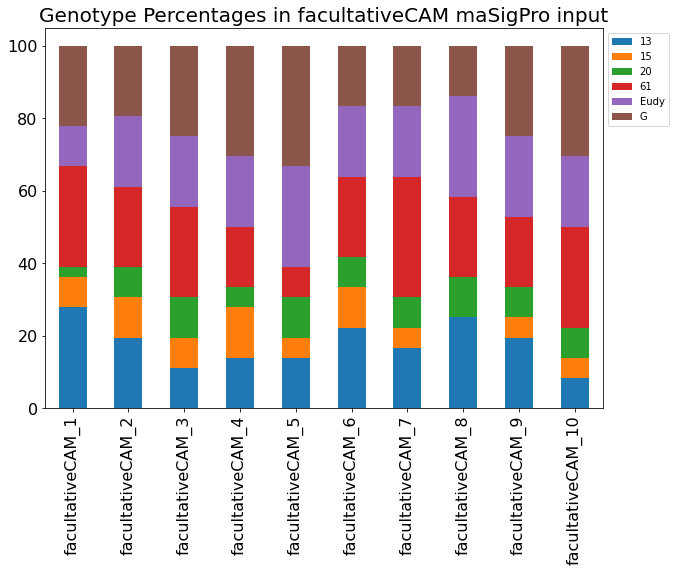

In [85]:
plot_gtpct("./facultativeCAM_inputdata_maSigPro/")

/tmp/ipykernel_380/944756710.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d,f),sep="\t",header="infer",usecols=["genotype"])
/tmp/ipykernel_380/944756710.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d,f),sep="\t",header="infer",usecols=["genotype"])
/tmp/ipykernel_380/944756710.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d,f),sep="\t",header="infer",usecols=["genotype"])
/tmp/ipykernel_380/944756710.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d,f),sep="\t",header="infer",usecols=["genotype"])
/tmp/ipykernel_380/944756710.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set

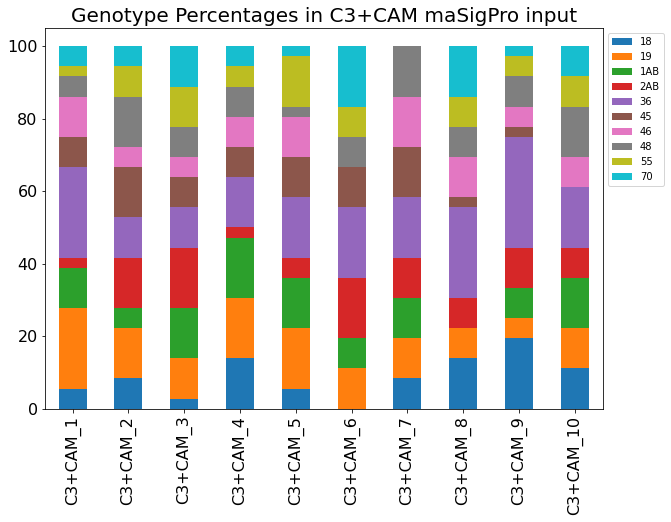

In [87]:
plot_gtpct("./C3+CAM_inputdata_maSigPro/")

In [13]:
# adjusted function 4/17/26 for C3+CAM
def plot_gtpct(d1,d2):
    phys = d1.split("_")[0].lstrip("./")
    md = {}
    for f in os.listdir(d1):
        if not f.startswith("."):
            n = f.split("_")[1]
            if n not in ["4","6","9"]:
                x = f.split("_")[0]+"_"+n
                md[x] = pd.read_csv(os.path.join(d1,f),sep="\t",header="infer",usecols=["genotype"])
    for f in os.listdir(d2):
        if not f.startswith("."):
            x = f.split("_")[0]+"_"+f.split("_")[1]
            md[x] = pd.read_csv(os.path.join(d2,f),sep="\t",header="infer",usecols=["genotype"])
        
    counts = {}
    for k, df in md.items():
        counts[k] = df["genotype"].astype(str).value_counts()

    counts_df = pd.DataFrame(counts).fillna(0)
    percent_df = counts_df.div(counts_df.sum(axis=0), axis=1) * 100
    percent_df = percent_df[[phys+"_1",phys+"_2",phys+"_3",phys+"_5",phys+"_7",phys+"_8",phys+"_10",phys+"_11",phys+"_12",phys+"_13"]]
    
    percent_df.T.plot(
        kind="bar",
        stacked=True,
        figsize=(10,7)
    )
    plt.legend(bbox_to_anchor=(1,1))
    plt.tick_params(which="both",labelsize=16)
    plt.title("Genotype Percentages in "+phys+" maSigPro input",fontsize=20)
    plt.savefig("./"+phys+"_gtpct.svg",dpi=300,bbox_inches="tight")

/tmp/ipykernel_1060/4045047638.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d1,f),sep="\t",header="infer",usecols=["genotype"])
/tmp/ipykernel_1060/4045047638.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d1,f),sep="\t",header="infer",usecols=["genotype"])
/tmp/ipykernel_1060/4045047638.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d1,f),sep="\t",header="infer",usecols=["genotype"])
/tmp/ipykernel_1060/4045047638.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  md[x] = pd.read_csv(os.path.join(d1,f),sep="\t",header="infer",usecols=["genotype"])
/tmp/ipykernel_1060/4045047638.py:14: DtypeWarning: Columns (1) have mixed types. Specify dtype opti

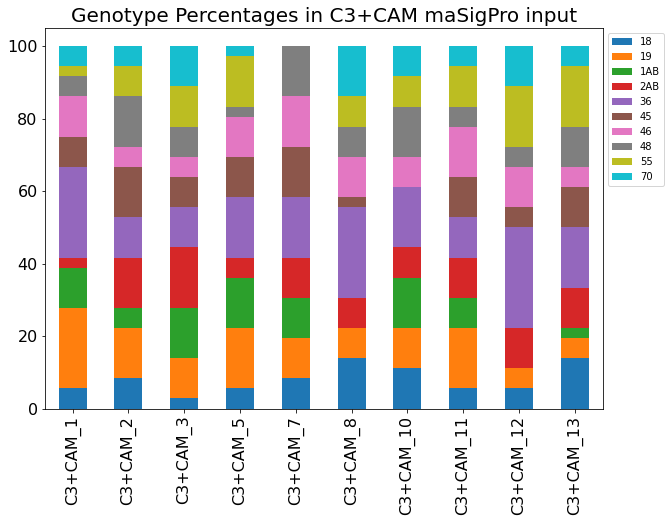

In [14]:
plot_gtpct("./C3+CAM_inputdata_maSigPro/","./C3+CAM_newsets_inputdata_maSigPro/")